In [1]:
import string
import textwrap

import dask.diagnostics
import faceted
import xarray as xr

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from upath import UPath

import plotting

In [2]:
CONTROL_ROOT = UPath("gs://vcm-ml-experiments/spencerc/2026-04-25-amip-inference")
PLUS_4K_ROOT = UPath("gs://vcm-ml-experiments/spencerc/2026-04-25-amip-plus-4K-inference")
MODELS = ["ACE2-SHiELD", "no-random-co2-energy-conserving-rs0", "full-energy-conserving-rs0"]

In [3]:
SECONDS_PER_DAY = 86400


def open_reference():
    control = xr.open_zarr("gs://vcm-ml-experiments/spencerc/2026-04-25-amip-inference/SHiELD-ic_0001/test/daily.zarr", decode_timedelta=False)
    plus_4k = xr.open_zarr("gs://vcm-ml-experiments/spencerc/2026-04-25-amip-plus-4K-data-only-inference/SHiELD/test/daily.zarr", decode_timedelta=False)
    ds = xr.concat([control, plus_4k], dim="case").assign_coords(case=["control", "plus-4K"])
    return ds.assign(PRATEsfc=SECONDS_PER_DAY * ds.PRATEsfc.assign_attrs(units="mm/day"))


def open_prediction(model: str):
    control = xr.open_zarr(str(CONTROL_ROOT / model / "test" / "daily.zarr"), decode_timedelta=False)
    plus_4k = xr.open_zarr(str(PLUS_4K_ROOT / model / "test" / "daily.zarr"), decode_timedelta=False)
    ds = xr.concat([control, plus_4k], dim="case").assign_coords(case=["control", "plus-4K"])
    return ds.assign(PRATEsfc=SECONDS_PER_DAY * ds.PRATEsfc.assign_attrs(units="mm/day"))


def open_datasets(models: list[str]):
    reference = open_reference()
    predictions = [open_prediction(model) for model in models]
    ds = xr.concat([reference, *predictions], dim="model").assign_coords(model=["SHiELD", *models])
    return ds.squeeze("sample")


In [4]:
ds = open_datasets(MODELS)

In [5]:
with dask.diagnostics.ProgressBar():
    extreme_precipitation = ds.PRATEsfc.quantile(0.999, dim=["time", "lon"]).compute()

[########################################] | 100% Completed | 592.83 s


In [6]:
COLORS = {
    "SHiELD": "k",
    "ACE2-SHiELD": "C0",
    "no-random-co2-energy-conserving-rs0": "C2",
    "full-energy-conserving-rs0": "C4",
}
MODEL_NAMES = {
    "SHiELD": "SHiELD",
    "ACE2-SHiELD": "ACE2-SHiELD",
    "no-random-co2-energy-conserving-rs0": "ACE2S-SHiELD+ w/o random CO$_2$ w/ energy conservation",
    "full-energy-conserving-rs0": "ACE2S-SHiELD+ w/ random CO$_2$ w/ energy conservation",
}

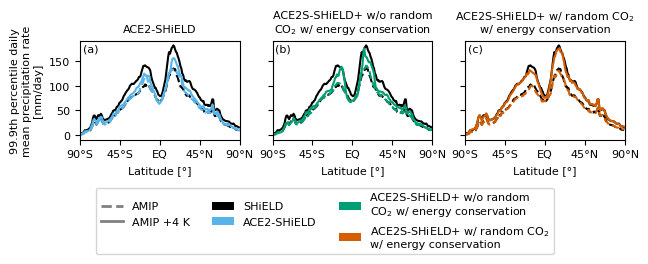

In [10]:
from typing import Any, Literal


plotting.configure_style()

fig, axes = faceted.faceted(1, 3, width=6.5, aspect=0.618, left_pad=0.8, bottom_pad=1.2, top_pad=0.4)

for ax, model, label in zip(axes, MODELS, string.ascii_lowercase):
    extreme_precipitation.sel(model="SHiELD", case="control").plot(ax=ax, color=COLORS["SHiELD"], ls="--")
    extreme_precipitation.sel(model="SHiELD", case="plus-4K").plot(ax=ax, color=COLORS["SHiELD"], ls="-")
    extreme_precipitation.sel(model=model, case="control").plot(ax=ax, color=COLORS[model], ls="--")
    extreme_precipitation.sel(model=model, case="plus-4K").plot(ax=ax, color=COLORS[model], ls="-")
    ax.set_title(textwrap.fill(MODEL_NAMES[model], width=30))
    ax.set_xlabel("Latitude [°]")
    ax.set_xticks([-90, -45, 0, 45, 90])
    ax.set_xticklabels([r"90°S", r"45°S", r"EQ", r"45°N", r"90°N"])
    ax.set_xlim(-90, 90)
    ax.set_ylabel("")

    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

axes[0].set_ylabel(textwrap.fill("99.9th percentile daily mean precipitation rate [mm/day]", width=25))

legend_elements = [
    Line2D([0], [0], color="gray", lw=2, ls="--", label="AMIP"),
    Line2D([0], [0], color="gray", lw=2, ls="-", label="AMIP +4 K"),
    Patch(facecolor="k", label=textwrap.fill(MODEL_NAMES["SHiELD"], width=30)),
    Patch(facecolor="C0", label=textwrap.fill(MODEL_NAMES["ACE2-SHiELD"], width=30)),
    Patch(facecolor="C2", label=textwrap.fill(MODEL_NAMES["no-random-co2-energy-conserving-rs0"], width=30)),
    Patch(facecolor="C4", label=textwrap.fill(MODEL_NAMES["full-energy-conserving-rs0"], width=30)),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.0),
    ncol=3,
    frameon=True
)

fig.patch.set_alpha(0.0)
fig.savefig("figure-S08.png", dpi=200)
fig.savefig("figure-S08.pdf")
